In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
import zipfile
import os


zipped_dataset_path = "/content/drive/MyDrive/AI ML/Data/Copy of Copy of devnagari digit.zip"


extraction_path = "/content/DevanagariHandwrittenDigitDataset_extracted"

os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zipped_dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Dataset unzipped to: {extraction_path}")



Dataset unzipped to: /content/DevanagariHandwrittenDigitDataset_extracted


In [ ]:

DATASET_PATH = "/content/DevanagariHandwrittenDigitDataset_extracted"
IMG_SIZE = (32, 32)

images = []
for root, dirs, files in os.walk(DATASET_PATH):
    for fname in files:
        if fname.lower().endswith(("png", "jpg", "jpeg")):
            img = Image.open(os.path.join(root, fname)).convert("L").resize(IMG_SIZE)
            images.append(np.array(img))

images = np.array(images, dtype="float32") / 255.0
images = images[..., np.newaxis]          # (N, 32, 32, 1)
print("Dataset shape:", images.shape)

Dataset shape: (20000, 32, 32, 1)


To unzip the dataset, we'll use Python's built-in `zipfile` module. You'll need to provide the path to your zipped file, and then we'll extract its contents to a new directory.

In [ ]:

x_train, x_val = train_test_split(images, test_size=0.1, random_state=42)
print("Train:", x_train.shape, "  Val:", x_val.shape)

Train: (18000, 32, 32, 1)   Val: (2000, 32, 32, 1)


In [ ]:

def add_gaussian_noise(x, noise_factor=0.4):
    noisy = x + noise_factor * np.random.randn(*x.shape)
    return np.clip(noisy, 0.0, 1.0)

def add_salt_pepper_noise(x, amount=0.05):
    noisy = x.copy()
    num_salt = int(np.ceil(amount * x.size * 0.5))
    coords = [np.random.randint(0, i, num_salt) for i in x.shape]
    noisy[tuple(coords)] = 1.0
    num_pepper = int(np.ceil(amount * x.size * 0.5))
    coords = [np.random.randint(0, i, num_pepper) for i in x.shape]
    noisy[tuple(coords)] = 0.0
    return noisy

NOISE_FACTOR = 0.4
x_train_noisy = add_gaussian_noise(x_train, NOISE_FACTOR)
x_val_noisy   = add_gaussian_noise(x_val,   NOISE_FACTOR)

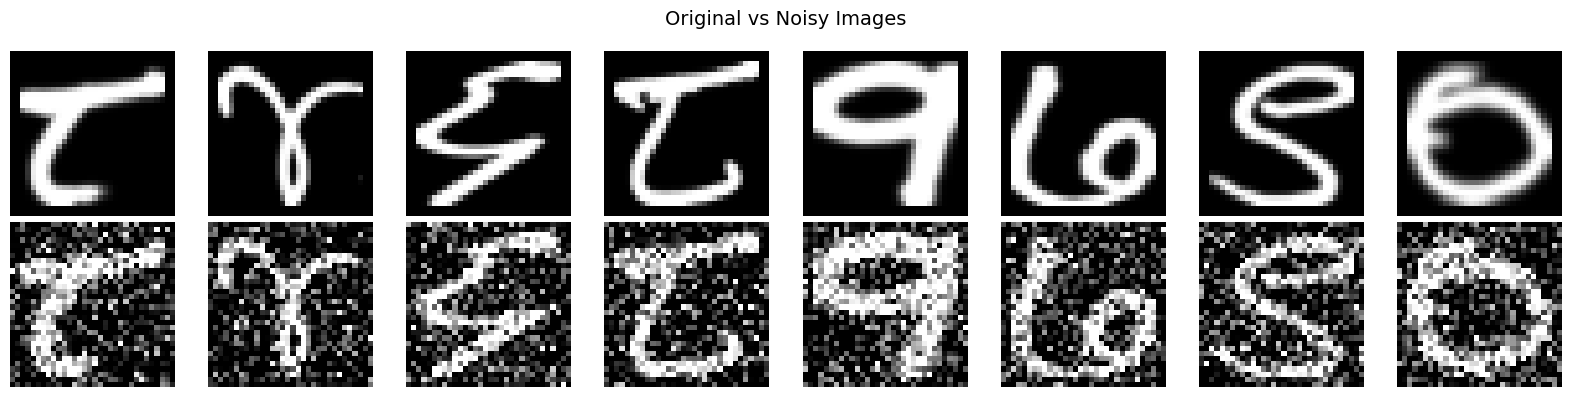

In [ ]:

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(x_train[i, ..., 0], cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(x_train_noisy[i, ..., 0], cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_ylabel("Clean", fontsize=12)
axes[1, 0].set_ylabel("Noisy", fontsize=12)
plt.suptitle("Original vs Noisy Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:

def build_autoencoder(input_shape=(32, 32, 1)):
    inp = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)          # 16x16
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)          # 8x8
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)          # 4x4
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D(2, padding="same")(x)    # 2x2

    # Decoder
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D(2)(x)                          # 4x4
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)                          # 8x8
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)                          # 16x16
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)                          # 32x32
    decoded = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

    autoencoder = models.Model(inp, decoded, name="DenoiseCAE")
    autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
    return autoencoder

model = build_autoencoder()
model.summary()

Model: "DenoiseCAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,365,505 (5.21 MB)

 Trainable params: 1,365,505 (5.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

EPOCHS     = 10
BATCH_SIZE = 64

early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    x_train_noisy, x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val_noisy, x_val),
    callbacks=[early_stop]
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 186s 644ms/step - loss: 0.3624 - val_loss: 0.2390
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 200s 638ms/step - loss: 0.2084 - val_loss: 0.1945
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 200s 630ms/step - loss: 0.1791 - val_loss: 0.1752
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 181s 642ms/step - loss: 0.1664 - val_loss: 0.1643
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 199s 630ms/step - loss: 0.1591 - val_loss: 0.1599
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 207s 646ms/step - loss: 0.1546 - val_loss: 0.1609
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 183s 648ms/step - loss: 0.1514 - val_loss: 0.1541
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 183s 647ms/step - loss: 0.1479 - val_loss: 0.1527
Epoch 9/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 201s 645ms/step - loss: 0.1460 - val_loss: 0.1538
Epoch 10/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 179s 634ms/step - loss: 0.1439 - val_loss: 0.1489


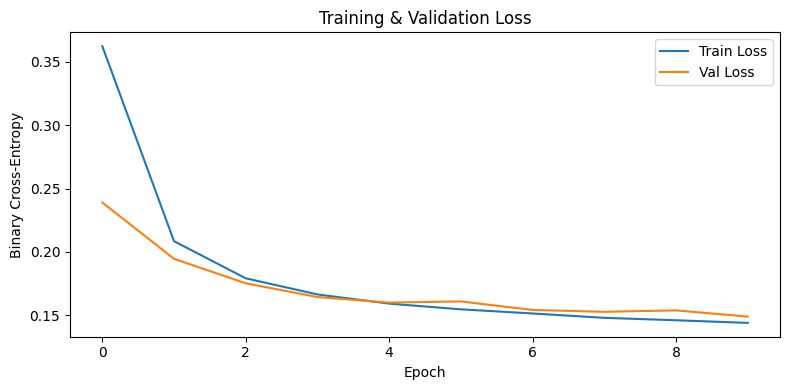

In [ ]:
# ── Loss Curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("Training & Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step


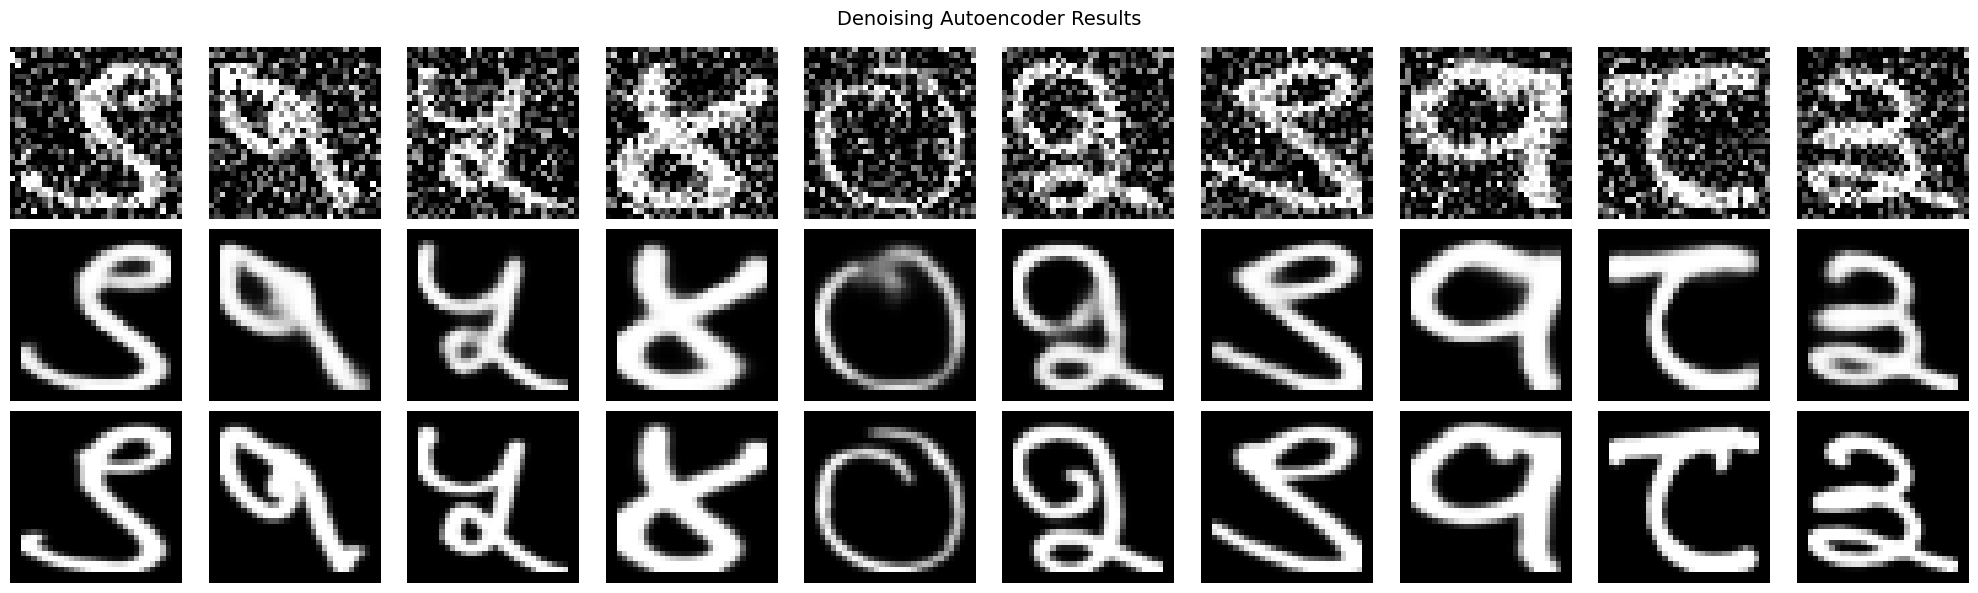

In [ ]:

denoised = model.predict(x_val_noisy[:10])

fig, axes = plt.subplots(3, 10, figsize=(20, 6))
titles = ["Noisy", "Denoised", "Original"]
data   = [x_val_noisy[:10], denoised, x_val[:10]]

for row, (title, imgs) in enumerate(zip(titles, data)):
    for col in range(10):
        axes[row, col].imshow(imgs[col, ..., 0], cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(title, fontsize=12)

plt.suptitle("Denoising Autoencoder Results", fontsize=14)
plt.tight_layout()
plt.show()